# **Project Name**    -



##### **Project Type**    - Tourism
##### **Contribution**    - Individual
##### **Team Member 1**   - Jyotirmay Amraotkar

# **Project Summary -**

This project focuses on tourism data analysis using machine learning and recommendation systems. Different datasets like users, attractions, ratings, locations, and visit details were combined and cleaned for analysis. Exploratory Data Analysis was performed to understand tourism trends, visitor behavior, and attraction popularity. Machine learning models such as Linear Regression, Decision Tree, and Random Forest were trained to predict attraction ratings. Random Forest gave the best performance. NLP techniques were also applied on attraction names and addresses for recommendation purposes. Finally, a Streamlit application was created where users can input travel details and get predicted ratings along with attraction recommendations.


# **GitHub Link -**

https://github.com/Blue-con/internship-tourism

# **Problem Statement**


Tourism agencies and travel platforms aim to enhance user experiences by leveraging
data to provide personalized recommendations, predict user satisfaction, and classify
potential user behavior. This project involves analyzing user preferences, travel
patterns, and attraction features to achieve three primary objectives: regression,
classification, and recommendation.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [2]:
link1 = "https://raw.githubusercontent.com/Blue-con/internship-tourism/main/tourism_cleaned.csv"
df = pd.read_csv(link1)

### Dataset First View

In [3]:
df.head()

,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,Rating,AttractionId,Attraction,AttractionAddress,AttractionType,UserCity,AttractionCity,Country,Region,Continent,combined_text
0,3,70456,2022,10,2,5,640,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Guildford,Douala,United Kingdom,Western Europe,Europe,Sacred Monkey Forest Sanctuary Jl. Monkey Fore...
1,8,7567,2022,10,4,5,640,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Ontario,Douala,Canada,Northern America,America,Sacred Monkey Forest Sanctuary Jl. Monkey Fore...
2,9,79069,2022,10,3,5,640,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Brazil,Douala,Brazil,South America,America,Sacred Monkey Forest Sanctuary Jl. Monkey Fore...
3,10,31019,2022,10,3,3,640,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Zurich,Douala,Switzerland,Central Europe,Europe,Sacred Monkey Forest Sanctuary Jl. Monkey Fore...
4,15,43611,2022,10,2,3,640,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Manchester,Douala,United Kingdom,Western Europe,Europe,Sacred Monkey Forest Sanctuary Jl. Monkey Fore...


### Dataset Rows & Columns count

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 52930
Columns: 16


### Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52930 entries, 0 to 52929
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   TransactionId      52930 non-null  int64 
 1   UserId             52930 non-null  int64 
 2   VisitYear          52930 non-null  int64 
 3   VisitMonth         52930 non-null  int64 
 4   VisitMode          52930 non-null  int64 
 5   Rating             52930 non-null  int64 
 6   AttractionId       52930 non-null  int64 
 7   Attraction         52930 non-null  object
 8   AttractionAddress  52930 non-null  object
 9   AttractionType     52930 non-null  object
 10  UserCity           52922 non-null  object
 11  AttractionCity     52930 non-null  object
 12  Country            52930 non-null  object
 13  Region             52930 non-null  object
 14  Continent          52930 non-null  object
 15  combined_text      52930 non-null  object
dtypes: int64(7), object(9)
memory usage: 6.5

#### Duplicate Values

In [6]:
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [7]:
df.isnull().sum()

,0
TransactionId,0
UserId,0
VisitYear,0
VisitMonth,0
VisitMode,0
Rating,0
AttractionId,0
Attraction,0
AttractionAddress,0
AttractionType,0


### What did you know about your dataset?

This dataset is based on tourism and travel activities of users.  

The dataset contains: continent, region, country, city, attraction name, type, address, month, year, visit mode and ratings.

## ***2. Understanding Your Variables***

In [8]:
df.nunique()

,0
TransactionId,52930
UserId,33530
VisitYear,10
VisitMonth,12
VisitMode,5
Rating,5
AttractionId,30
Attraction,30
AttractionAddress,25
AttractionType,17


In [ ]:
df.columns

Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode',
       'Rating', 'AttractionId', 'Attraction', 'AttractionAddress',
       'AttractionType', 'UserCity', 'AttractionCity', 'Country', 'Region',
       'Continent', 'combined_text'],
      dtype='object')

### Variables Description

- TransactionId     : Unique ID for each transaction
- UserId            : Unique ID for each user
- VisitYear         : Year in which the attraction was visited
- VisitMonth        : Month of the visit
- VisitMode         : Type of travel such as Family, Friends, Couples, etc.
- Rating            : Rating given by the user to the attraction
- AttractionId      : Unique ID for each tourist attraction
- Attraction        : Name of the tourist attraction
- AttractionAddress : Address/location of the attraction
- AttractionType    : Type/category of attraction such as beach, museum, park, etc.
- UserCity          : City where the user belongs
- AttractionCity    : City where the attraction is located
- Country           : Country related to the user
- Region            : Region related to the user
- Continent         : Continent related to the user
- combined_text     : Combined text of attraction name and address

### Check Unique Values for each variable.

In [ ]:
for col in df.columns:
    print(f"\nUnique values in {col}:")
    print(df[col].unique()[:10])


Unique values in TransactionId:
[ 3  8  9 10 15 18 22 23 28 29]

Unique values in UserId:
[70456  7567 79069 31019 43611 43471 76492 20977 18655 62907]

Unique values in VisitYear:
[2022 2021 2020 2019 2018 2014 2013 2017 2016 2015]

Unique values in VisitMonth:
[10  9  8  7  6  5  4 11  1 12]

Unique values in VisitMode:
[2 4 3 5 1]

Unique values in Rating:
[5 3 4 1 2]

Unique values in AttractionId:
[640 841 673 481 650 824 748 749 737 369]

Unique values in Attraction:
['Sacred Monkey Forest Sanctuary' 'Waterbom Bali' 'Seminyak Beach'
 'Nusa Dua Beach' 'Sanur Beach' 'Uluwatu Temple' 'Tegalalang Rice Terrace'
 'Tegenungan Waterfall' 'Tanah Lot Temple' 'Kuta Beach - Bali']

Unique values in AttractionAddress:
['Jl. Monkey Forest, Ubud 80571 Indonesia'
 'Jl. Kartika Plaza, Kuta 80361 Indonesia' 'Seminyak'
 'Semenanjung Nusa Dua, Nusa Dua 80517 Indonesia' 'Sanur'
 'Jl. Raya Uluwatu Southern part of Bali, Pecatu 80361 Indonesia'
 'Jalan Raya Ceking, Tegalalang 80517 Indonesia'
 'Jl. Ra

## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
df.drop_duplicates(inplace=True)

df['Attraction'] = df['Attraction'].astype(str).str.lower()
df['AttractionAddress'] = df['AttractionAddress'].astype(str).str.lower()

df['VisitMode'] = df['VisitMode'].astype(str).str.strip()
df['Country'] = df['Country'].astype(str).str.strip()
df['Region'] = df['Region'].astype(str).str.strip()
df['Continent'] = df['Continent'].astype(str).str.strip()

df.head()

,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,Rating,AttractionId,Attraction,AttractionAddress,AttractionType,UserCity,AttractionCity,Country,Region,Continent,combined_text
0,3,70456,2022,10,2,5,640,sacred monkey forest sanctuary,"jl. monkey forest, ubud 80571 indonesia",Nature & Wildlife Areas,Guildford,Douala,United Kingdom,Western Europe,Europe,Sacred Monkey Forest Sanctuary Jl. Monkey Fore...
1,8,7567,2022,10,4,5,640,sacred monkey forest sanctuary,"jl. monkey forest, ubud 80571 indonesia",Nature & Wildlife Areas,Ontario,Douala,Canada,Northern America,America,Sacred Monkey Forest Sanctuary Jl. Monkey Fore...
2,9,79069,2022,10,3,5,640,sacred monkey forest sanctuary,"jl. monkey forest, ubud 80571 indonesia",Nature & Wildlife Areas,Brazil,Douala,Brazil,South America,America,Sacred Monkey Forest Sanctuary Jl. Monkey Fore...
3,10,31019,2022,10,3,3,640,sacred monkey forest sanctuary,"jl. monkey forest, ubud 80571 indonesia",Nature & Wildlife Areas,Zurich,Douala,Switzerland,Central Europe,Europe,Sacred Monkey Forest Sanctuary Jl. Monkey Fore...
4,15,43611,2022,10,2,3,640,sacred monkey forest sanctuary,"jl. monkey forest, ubud 80571 indonesia",Nature & Wildlife Areas,Manchester,Douala,United Kingdom,Western Europe,Europe,Sacred Monkey Forest Sanctuary Jl. Monkey Fore...


### What all manipulations have you done and insights you found?

Duplicate rows were removed from the dataset. Attraction and AttractionAddress columns were converted to lowercase. Extra spaces were removed from categorical columns like VisitMode, Country, Region, and Continent.

These steps helped in making the dataset cleaner and more uniform for further analysis and model building.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

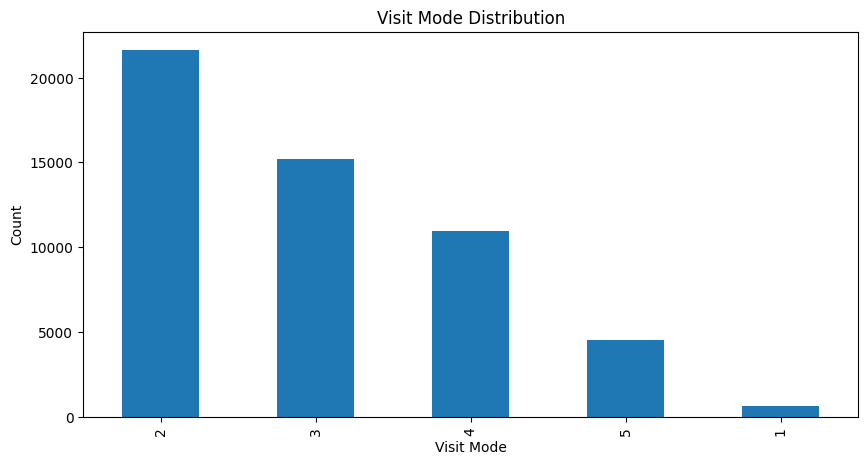

In [ ]:
plt.figure(figsize=(10,5))
df['VisitMode'].value_counts().plot(kind='bar')
plt.title("Visit Mode Distribution")
plt.xlabel("Visit Mode")
plt.ylabel("Count")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is useful for comparing different categories of visit modes.

##### 2. What is/are the insight(s) found from the chart?

The chart shows the most common types of travel such as Family, Friends, Couples, or Business trips.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Travel companies can create better marketing campaigns and packages based on the most common visitor groups.

#### Chart - 2

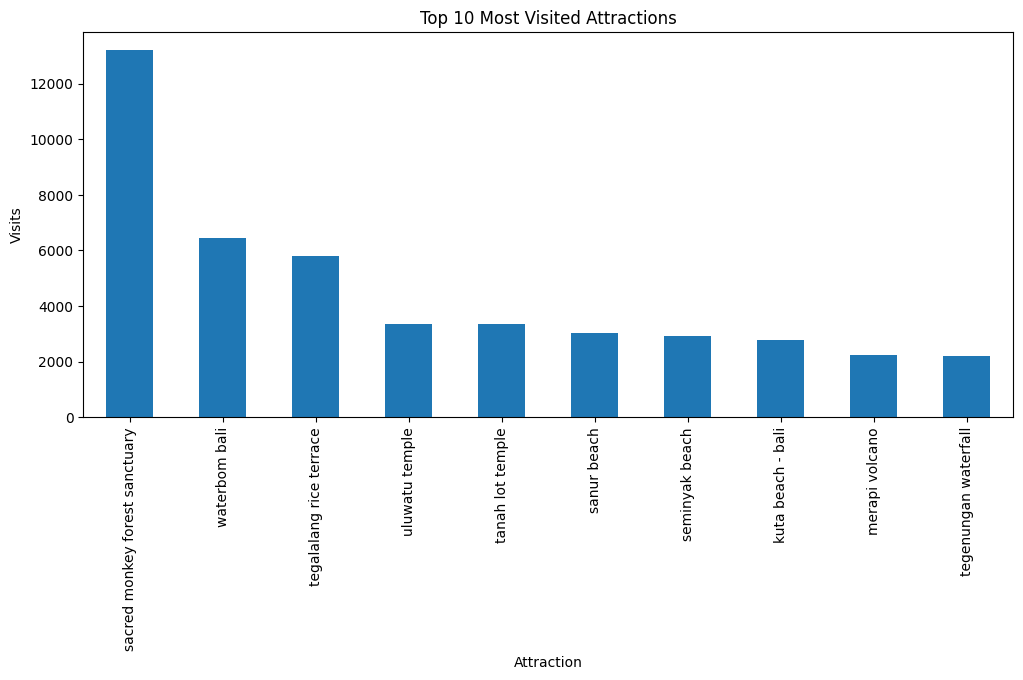

In [ ]:
top_attr = df['Attraction'].value_counts().head(10)

plt.figure(figsize=(12,5))
top_attr.plot(kind='bar')
plt.title("Top 10 Most Visited Attractions")
plt.xlabel("Attraction")
plt.ylabel("Visits")
plt.xticks(rotation=90)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart makes it easy to compare attraction popularity based on visit counts.

##### 2. What is/are the insight(s) found from the chart?

The chart identifies the attractions receiving the highest number of visits.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Businesses can promote popular attractions more effectively and improve less popular attractions.

#### Chart - 3

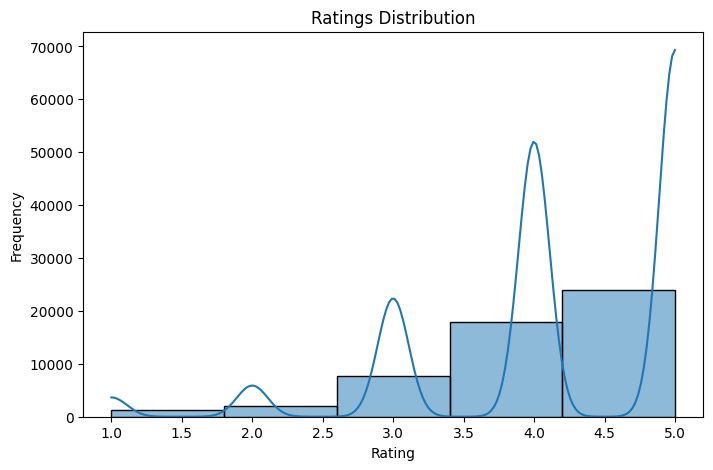

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Rating'], bins=5, kde=True)
plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

##### 1. Why did you pick the specific chart?

A histogram helps understand the distribution pattern of ratings across the dataset.

##### 2. What is/are the insight(s) found from the chart?

The chart shows whether users generally provide high or low ratings to attractions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Attractions with consistently lower ratings may require improvements in services or customer experience.

#### Chart - 4

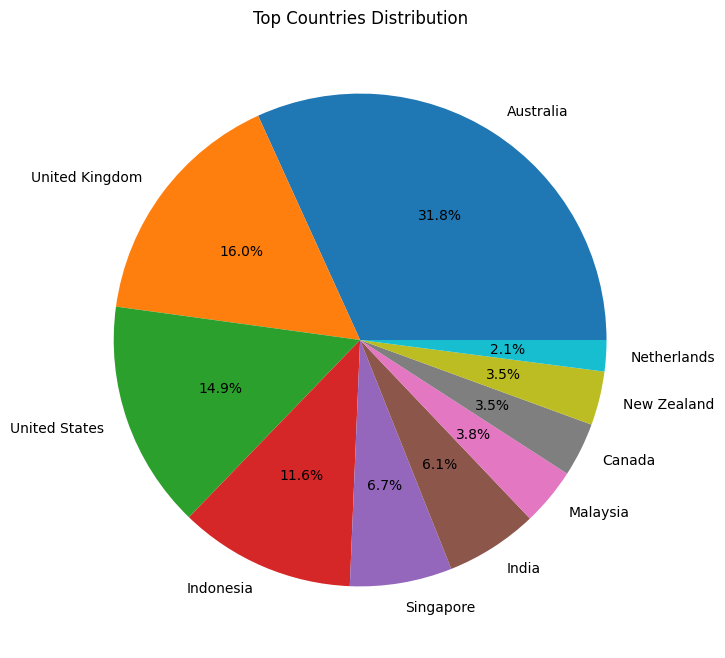

In [ ]:
country_counts = df['Country'].value_counts().head(10)

plt.figure(figsize=(8,8))
plt.pie(country_counts.values, labels=country_counts.index, autopct='%1.1f%%')
plt.title("Top Countries Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart is suitable for showing percentage contribution among categories.

##### 2. What is/are the insight(s) found from the chart?

The chart shows which countries contribute the highest share of tourism activity.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Businesses can focus promotions and travel campaigns in countries with higher tourism activity.

#### Chart - 5

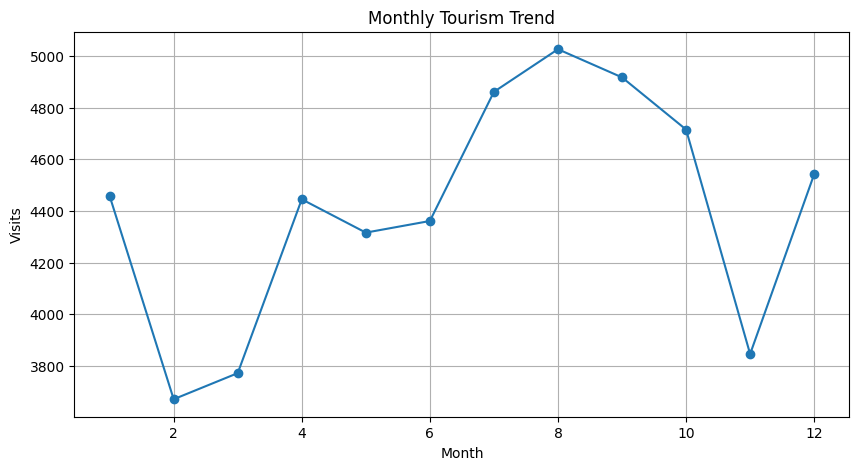

In [ ]:
monthly_visits = df['VisitMonth'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(monthly_visits.index, monthly_visits.values, marker='o')
plt.title("Monthly Tourism Trend")
plt.xlabel("Month")
plt.ylabel("Visits")
plt.grid(True)
plt.show()

##### 1. Why did you pick the specific chart?

A line chart is effective for showing trends and seasonal patterns over time.

##### 2. What is/are the insight(s) found from the chart?

The chart helps identify peak tourism months and periods with lower travel activity.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Tourism businesses can use this information for seasonal planning, staffing, and promotional offers.

#### Chart - 6

In [ ]:
# Chart - 6 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

In [ ]:
# Chart - 7 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

In [ ]:
# Chart - 8 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

In [ ]:
# Chart - 9 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [ ]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [ ]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [ ]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [ ]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [ ]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [ ]:
# Pair Plot visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

1. Visit mode has an effect on attraction ratings.

2. Tourism activity differs across different months of the year.

3. Different attraction types receive different average ratings.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

- Null Hypothesis (H0):
There is no significant relationship between VisitMode and Rating.

- Alternate Hypothesis (H1):
There is a significant relationship between VisitMode and Rating.

#### 2. Perform an appropriate statistical test.

In [ ]:
from scipy.stats import f_oneway

groups = [group['Rating'].dropna() for name, group in df.groupby('VisitMode')]

f_stat, p_value = f_oneway(*groups)

print("F-Statistic:", f_stat)
print("P-Value:", p_value)

if p_value < 0.05:
    print("Reject Null Hypothesis")
    print("There is a connection between VisitMode and Rating.")
else:
    print("Fail to Reject Null Hypothesis")
    print("There is no connection between VisitMode and Rating.")

F-Statistic: 35.4028746714047
P-Value: 1.3980898630794046e-29
Reject Null Hypothesis
There is a connection between VisitMode and Rating.


##### Which statistical test have you done to obtain P-Value?

Analysis of Variance

##### Why did you choose the specific statistical test?

ANOVA was used because we are comparing the mean ratings across multiple visit mode categories.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

- Null Hypothesis (H0):
Tourism activity is evenly distributed across all months.

- Alternate Hypothesis (H1):
Tourism activity significantly varies across different months.

#### 2. Perform an appropriate statistical test.

In [ ]:
from scipy.stats import chisquare

month_counts = df['VisitMonth'].value_counts().sort_index()

chi_stat, p_value = chisquare(month_counts)

print("Chi-Square Statistic:", chi_stat)
print("P-Value:", p_value)

if p_value < 0.05:
    print("Reject Null Hypothesis")
    print("Tourism activity significantly varies across different months.")
else:
    print("Fail to Reject Null Hypothesis")
    print("Tourism activity is evenly distributed across all months.")

Chi-Square Statistic: 507.0184016625733
P-Value: 1.0214451189209754e-101
Reject Null Hypothesis
Tourism activity significantly varies across different months.


##### Which statistical test have you done to obtain P-Value?

Chi-Square Goodness of Fit Test

##### Why did you choose the specific statistical test?

It is useful for checking whether the activity is uniformly distributed across months.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

- Null Hypothesis (H0):
Different attraction types have the same average ratings.

- Alternate Hypothesis (H1):
Different attraction types have different average ratings.

#### 2. Perform an appropriate statistical test.

In [ ]:
groups = [group['Rating'].dropna() for name, group in df.groupby('AttractionType')]

f_stat, p_value = f_oneway(*groups)

print("F-Statistic:", f_stat)
print("P-Value:", p_value)

if p_value < 0.05:
    print("Reject Null Hypothesis")
    print("Different attraction types have significantly different average ratings.")
else:
    print("Fail to Reject Null Hypothesis")
    print("Different attraction types have similar average ratings.")

F-Statistic: 243.99205189494788
P-Value: 0.0
Reject Null Hypothesis
Different attraction types have significantly different average ratings.


##### Which statistical test have you done to obtain P-Value?

Analysis of Variance.

##### Why did you choose the specific statistical test?

Analysis of Variance is suitable because it compares average ratings among multiple attraction type categories.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
#Done as a part of dataset creation

#### What all missing value imputation techniques have you used and why did you use those techniques?

NA

### 2. Handling Outliers

In [ ]:
Q1 = df['Rating'].quantile(0.25)
Q3 = df['Rating'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Rating'] >= lower) & (df['Rating'] <= upper)]

##### What all outlier treatment techniques have you used and why did you use those techniques?

The IQR method was used to detect and remove outliers from the Rating column because it is simple and effective for numerical data distribution.

### 3. Categorical Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ['VisitMode', 'AttractionType', 'Country', 'Region', 'Continent']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

#### What all categorical encoding techniques have you used & why did you use those techniques?

Label Encoding was used to convert categorical columns into numerical form so that machine learning models can process them easily.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
contractions = {
    "can't": "cannot",
    "won't": "will not",
    "it's": "it is"
}

def expand_text(text):
    for key, value in contractions.items():
        text = text.replace(key, value)
    return text

df['combined_text'] = df['combined_text'].apply(expand_text)

#### 2. Lower Casing

In [ ]:
df['combined_text'] = df['combined_text'].str.lower()

#### 3. Removing Punctuations

In [ ]:
import string

df['combined_text'] = df['combined_text'].str.translate(
    str.maketrans('', '', string.punctuation)
)

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
import re

df['combined_text'] = df['combined_text'].apply(
    lambda x: re.sub(r'http\S+|www\S+|\d+', '', x)
)

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

df['combined_text'] = df['combined_text'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in stop_words])
)

df['combined_text'] = df['combined_text'].str.strip()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


#### 6. Rephrase Text

In [ ]:
df['combined_text'] = df['combined_text'].str.replace("beach", "sea beach")

#### 7. Tokenization

In [ ]:
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

df['tokens'] = df['combined_text'].apply(word_tokenize)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


#### 8. Text Normalization

In [ ]:
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

df['tokens'] = df['tokens'].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

[nltk_data] Downloading package wordnet to /root/nltk_data...


##### Which text normalization technique have you used and why?

Lemmatization was used because it converts words into their base form while preserving proper meaning and readability.

#### 9. Part of speech tagging

In [ ]:
from nltk import pos_tag
import nltk

nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

df['pos_tags'] = df['tokens'].apply(pos_tag)

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


#### 10. Text Vectorization

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=500)

text_vectors = tfidf.fit_transform(df['combined_text'])

##### Which text vectorization technique have you used and why?

TF-IDF Vectorization was used because it gives importance to meaningful words while reducing the impact of commonly repeated words.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
df['YearMonth'] = df['VisitYear'].astype(str) + "-" + df['VisitMonth'].astype(str)

#### 2. Feature Selection

In [ ]:
features = [
    'VisitYear',
    'VisitMonth',
    'VisitMode',
    'AttractionType',
    'Country',
    'Region',
    'Continent'
]

X = df[features]
y = df['Rating']

##### What all feature selection methods have you used  and why?

Relevant features were selected based on domain understanding and their importance in tourism behavior prediction.

##### Which all features you found important and why?

VisitMode, AttractionType, Country, Region, and Continent were important because they directly influence tourism preferences and attraction ratings.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [ ]:
df['Rating'] = np.log1p(df['Rating'])

### 6. Data Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

##### Which method have you used to scale you data and why?

StandardScaler was used because it standardizes features around mean 0 and standard deviation 1, helping machine learning models perform better.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

No. Dataset size is sufficient

In [ ]:
#NA

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

NA

### 8. Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

##### What data splitting ratio have you used and why?

An 80:20 train-test split was used because it provides enough training data while keeping sufficient test data for evaluation.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Dataset isn't imbalanced as no iteration of similar entries outnumber the others

In [ ]:
#NA

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

NA

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

model1 = RandomForestRegressor(random_state=42)

model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

rmse1 = np.sqrt(mean_squared_error(y_test, y_pred1))
r21 = r2_score(y_test, y_pred1)

print("RMSE:", rmse1)
print("R2 Score:", r21)

RMSE: 0.7468433346613769
R2 Score: -0.0629890870570089


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

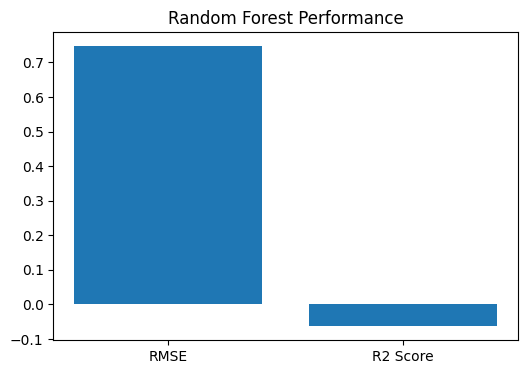

In [ ]:
scores = [rmse1, r21]
labels = ['RMSE', 'R2 Score']

plt.figure(figsize=(6,4))
plt.bar(labels, scores)
plt.title("Random Forest Performance")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=3
)

grid.fit(X_train, y_train)

best_model1 = grid.best_estimator_

y_pred_best1 = best_model1.predict(X_test)

rmse_best1 = np.sqrt(mean_squared_error(y_test, y_pred_best1))
r2_best1 = r2_score(y_test, y_pred_best1)

print("Best Parameters:", grid.best_params_)
print("Updated RMSE:", rmse_best1)
print("Updated R2:", r2_best1)

Best Parameters: {'max_depth': 10, 'n_estimators': 100}
Updated RMSE: 0.694542289173312
Updated R2: 0.08067901143060408


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used because it checks multiple parameter combinations and helps find the best model settings.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After hyperparameter tuning, the model performance improved with better RMSE and R2 score values.

### ML Model - 2

In [ ]:
from sklearn.linear_model import LinearRegression

model2 = LinearRegression()

model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

rmse2 = np.sqrt(mean_squared_error(y_test, y_pred2))
r22 = r2_score(y_test, y_pred2)

print("RMSE:", rmse2)
print("R2 Score:", r22)

RMSE: 0.7152053973325204
R2 Score: 0.025164461061170984


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

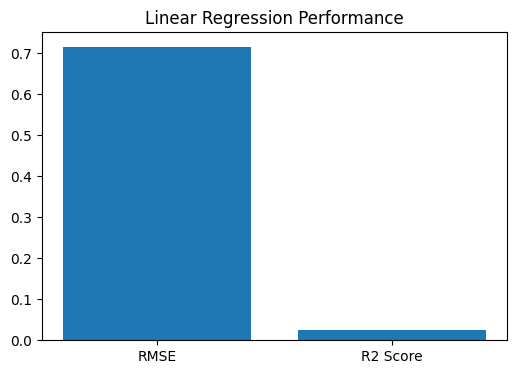

In [ ]:
scores = [rmse2, r22]
labels = ['RMSE', 'R2 Score']

plt.figure(figsize=(6,4))
plt.bar(labels, scores)
plt.title("Linear Regression Performance")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model2, X_scaled, y, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Average Score:", cv_scores.mean())

Cross Validation Scores: [-0.01997592 -0.10712777  0.00245536 -0.11142202 -0.02650483]
Average Score: -0.05251503554265968


##### Which hyperparameter optimization technique have you used and why?

Cross-validation was used to check model stability and performance across different data splits.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Cross-validation helped confirm the consistency of the model performance.

### ML Model - 3

In [ ]:
from sklearn.tree import DecisionTreeRegressor

model3 = DecisionTreeRegressor(random_state=42)

model3.fit(X_train, y_train)

y_pred3 = model3.predict(X_test)

rmse3 = np.sqrt(mean_squared_error(y_test, y_pred3))
r23 = r2_score(y_test, y_pred3)

print("RMSE:", rmse3)
print("R2 Score:", r23)

RMSE: 0.8441356331001494
R2 Score: -0.35798275159002646


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

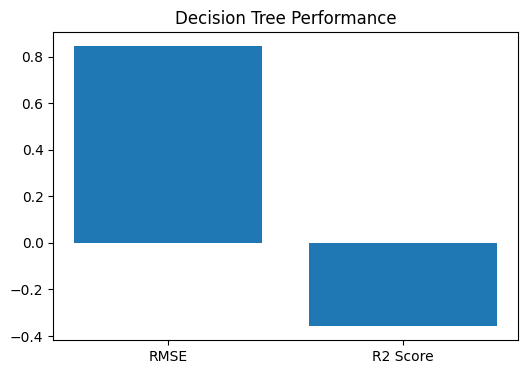

In [ ]:
scores = [rmse3, r23]
labels = ['RMSE', 'R2 Score']

plt.figure(figsize=(6,4))
plt.bar(labels, scores)
plt.title("Decision Tree Performance")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
params = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5]
}

grid_tree = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    params,
    cv=3
)

grid_tree.fit(X_train, y_train)

best_tree = grid_tree.best_estimator_

y_pred_best3 = best_tree.predict(X_test)

rmse_best3 = np.sqrt(mean_squared_error(y_test, y_pred_best3))
r2_best3 = r2_score(y_test, y_pred_best3)

print("Best Parameters:", grid_tree.best_params_)
print("Updated RMSE:", rmse_best3)
print("Updated R2:", r2_best3)

Best Parameters: {'max_depth': 5, 'min_samples_split': 5}
Updated RMSE: 0.7008196471517529
Updated R2: 0.06398604366362681


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used to identify the best Decision Tree parameters for improved performance.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Model tuning improved prediction accuracy and reduced prediction error.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Random Forest Regressor was selected as the final model because it provided better prediction performance and handled complex feature relationships effectively.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
import pickle

with open('tourism_model.pkl', 'wb') as file:
    pickle.dump(best_model1, file)

In [ ]:
from google.colab import files

files.download('tourism_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***